# B-cell receptor repertoire analysis with `ov.airr`

When you are vaccinated, the immune response is *written into the B-cell
receptor (BCR) repertoire*. Each naive B cell carries a unique
immunoglobulin heavy chain (IgH), assembled by V(D)J recombination. On
encountering antigen, responding B cells enter germinal centres and undergo
**affinity maturation** — a Darwinian cycle of:

1. **Clonal expansion** — antigen-specific B cells proliferate, so their IgH
   sequences come to dominate the repertoire.
2. **Somatic hypermutation (SHM)** — the enzyme AID introduces point
   mutations into the rearranged V(D)J at a rate ~10^6-fold above background.
3. **Selection** — variants with higher antigen affinity are preferentially
   retained; the mutations that improve binding accumulate in the
   antigen-contacting **CDRs**, while the structural **framework regions
   (FWRs)** are kept intact by purifying selection.
4. **Class switching** — selected clones switch from IgM/IgD to IgG/IgA.

A BCR repertoire snapshot therefore carries a *molecular fossil record* of
this process. This tutorial reconstructs that record.

## The dataset

We use the **Laserson et al. 2014** influenza-vaccination IgH repertoire
(*PNAS* 2014, [PMID 24639495](https://pubmed.ncbi.nlm.nih.gov/24639495/)) --
high-throughput IgH sequencing from **one subject** at **two timepoints**:
**pre-vaccination (`-1h`)** and **day 7 post-vaccination (`+7d`)**, the peak
of the plasmablast response. The data are in standard **AIRR rearrangement
format**: one row per IgH sequence, with V/D/J gene calls, the CDR3 junction,
and IMGT-numbered alignments to the inferred germline.

## What `ov.airr` provides

`ov.airr` threads the **Immcantation** B-cell toolchain behind one registered
API -- clonal clustering (`pyscoper`), somatic hypermutation and BASELINe
selection (`pyshazam`), Ig genotyping (`pytigger`) and B-cell phylogenetics
(`pydowser`). Functions take a plain AIRR-format `pandas.DataFrame`, so the
whole analysis stays tabular and inspectable.

## 0. Setup

The B-cell side of `ov.airr` is table-native -- there is no AnnData here, just
an AIRR `DataFrame` that each step annotates with new columns.

In [1]:
import omicverse as ov
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the IgH repertoire

`ov.datasets.airr_bcr()` returns the Laserson 2014 IgH table as an
AIRR-format `DataFrame`. Each row is one rearranged heavy chain.

In [2]:
bcr = ov.datasets.airr_bcr()
print(f"sequences: {bcr.shape[0]}   columns: {bcr.shape[1]}")
print(f"timepoints: {bcr['sample_id'].value_counts().to_dict()}")
print(f"isotypes:   {bcr['c_call'].value_counts().to_dict()}")

🔍 Downloading data to ./data/bcr_repertoire.tsv.gz
⚠️ File ./data/bcr_repertoire.tsv.gz already exists
sequences: 1999   columns: 24
timepoints: {'-1h': 1000, '+7d': 999}
isotypes:   {'IGHM': 718, 'IGHG': 650, 'IGHA': 372, 'IGHD': 259}


The key AIRR columns the B-cell pipeline relies on:

| column | meaning |
|---|---|
| `sequence_alignment` | the observed IgH V(D)J, IMGT-gapped |
| `germline_alignment_d_mask` | the inferred **unmutated germline**, D-region masked with `N` |
| `v_call` / `j_call` / `c_call` | V gene, J gene, constant region (isotype) |
| `junction` | the CDR3 nucleotide sequence (the V-D-J join) |
| `sample_id` | timepoint -- `-1h` (pre) or `+7d` (day 7) |

Comparing `sequence_alignment` against `germline_alignment_d_mask`
position-by-position is exactly how somatic hypermutation is quantified. We
keep only **productive** rearrangements (functional, in-frame, no stop
codons) -- only these encode a real receptor.

In [3]:
db = bcr[bcr['productive'] == 'T'].copy()
print(f"productive sequences: {len(db)}  ({len(bcr) - len(db)} non-productive dropped)")
iso = ov.airr.isotype_class(db, mapping={'IGHM': 'naive (IgM/IgD)',
                                         'IGHD': 'naive (IgM/IgD)',
                                         'IGHG': 'switched (IgG/IgA)',
                                         'IGHA': 'switched (IgG/IgA)'})
print(iso.value_counts().to_dict())

productive sequences: 1780  (219 non-productive dropped)
{'naive (IgM/IgD)': 922, 'switched (IgG/IgA)': 858}


About 60% of the productive sequences are still **naive** (IgM/IgD) and
40% are **class-switched** (IgG/IgA) -- the switched fraction is the
antigen-experienced, affinity-matured compartment we expect to grow after
vaccination.

## 2. Immunoglobulin gene usage

Before tracing the vaccine response we describe the *raw material* of the
repertoire: which **germline V, D and J gene segments** the subject's B cells
recombined. V(D)J recombination is not uniform -- a handful of IGHV gene
families (especially **IGHV3** and **IGHV4**) dominate the human heavy-chain
repertoire, and the usage profile is a useful sanity check and a baseline for
the antigen-driven skewing we look for later.

`ov.airr.bcr_gene_usage` wraps `pyalakazam.countGenes`. With `mode='family'`
it collapses alleles to the gene-**family** level; `seq_freq` is the fraction
of sequences using each family.

In [4]:
usage_v = ov.airr.bcr_gene_usage(db, gene='v_call', mode='family')
usage_v = usage_v.sort_values('seq_freq', ascending=False)
print("IGHV family usage across the productive repertoire:")
print(usage_v[['gene', 'seq_count', 'seq_freq']].to_string(index=False))

IGHV family usage across the productive repertoire:
 gene  seq_count  seq_freq
IGHV3       1118  0.628090
IGHV4        265  0.148876
IGHV1        201  0.112921
IGHV2         95  0.053371
IGHV5         86  0.048315
IGHV6         15  0.008427


The repertoire is dominated by **IGHV3** and **IGHV4** -- together
roughly three-quarters of all heavy chains -- exactly the textbook human IgH
family hierarchy. The J side is far less diverse (only six functional IGHJ
genes exist), so a single gene usually carries most sequences.

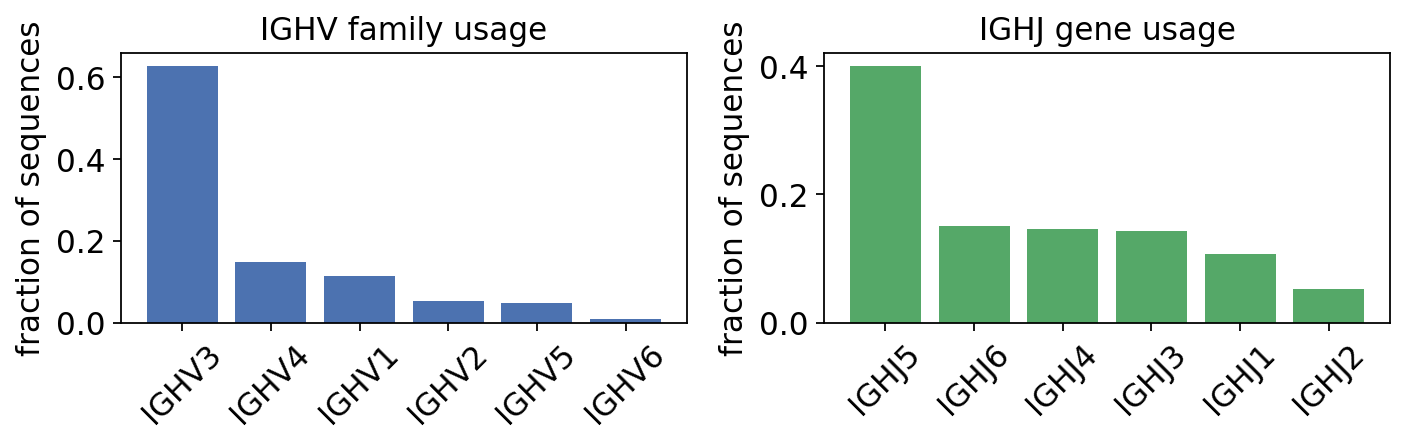

In [5]:
usage_j = ov.airr.bcr_gene_usage(db, gene='j_call', mode='gene')
usage_j = usage_j.sort_values('seq_freq', ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].bar(usage_v['gene'], usage_v['seq_freq'], color='#4C72B0')
ax[1].bar(usage_j['gene'], usage_j['seq_freq'], color='#55A868')
ax[0].set_title('IGHV family usage'); ax[1].set_title('IGHJ gene usage')
for a in ax:
    a.set_ylabel('fraction of sequences')
    a.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

### Does gene usage differ by isotype?

If antigen experience reshapes the repertoire, the **class-switched**
(IgG/IgA) compartment may use a different V-gene mix from the **naive**
(IgM/IgD) one. Passing `groups='c_call'` tabulates usage separately per
isotype.

In [6]:
pivot = ov.airr.bcr_gene_usage(db, gene='v_call', mode='family',
                               groups='c_call', pivot=True)
pivot = pivot.loc[['IGHV1', 'IGHV3', 'IGHV4', 'IGHV5']]
print("IGHV family fraction by isotype:")
print(pivot.round(3).to_string())

IGHV family fraction by isotype:
c_call   IGHA   IGHD   IGHG   IGHM
gene                              
IGHV1   0.060  0.194  0.020  0.184
IGHV3   0.768  0.463  0.899  0.403
IGHV4   0.119  0.227  0.067  0.201
IGHV5   0.033  0.062  0.013  0.079


The big families (IGHV3, IGHV4) are used by every isotype, but the
fine balance shifts between the naive and switched compartments -- a first
hint that the antigen-experienced repertoire is not just a mutated copy of
the naive one. Gene usage is **clone-weightable** too: passing
`clone='clone_id'` would count each clone once, so a single hugely expanded
lineage cannot distort the profile.

## 3. Clonal inference -- who shares a B-cell ancestor?

A **B-cell clone** is the set of sequences descended from a single
V(D)J-recombined naive cell. They share the same V and J genes and a
near-identical CDR3 (the junction), but differ by the point mutations SHM has
since introduced. Grouping sequences into clones is the foundation for
everything downstream -- SHM, selection and lineage trees are all
*per-clone* analyses.

### The distance-to-nearest threshold

How similar must two junctions be to call them clonally related? We let the
data answer. `ov.airr.distance_threshold` computes, for every sequence, the
distance to its **nearest neighbour** of the same V/J/junction-length, then
fits a threshold in the valley of that distribution.

In [7]:
threshold, db_dist = ov.airr.distance_threshold(db, model='ham', first=True)
dist = db_dist['dist_nearest'].dropna()
print(f"inferred clonal threshold: {threshold:.3f}")
print(f"sequences with a same-VJL neighbour: {len(dist)}")

inferred clonal threshold: 0.168
sequences with a same-VJL neighbour: 1744


The distance-to-nearest histogram is **bimodal**: a low-distance mode
(sequences that *are* clonally related -- same clone, separated only by SHM)
and a high-distance mode (sequences from unrelated rearrangements). A good
clonal threshold sits in the **valley** between them.

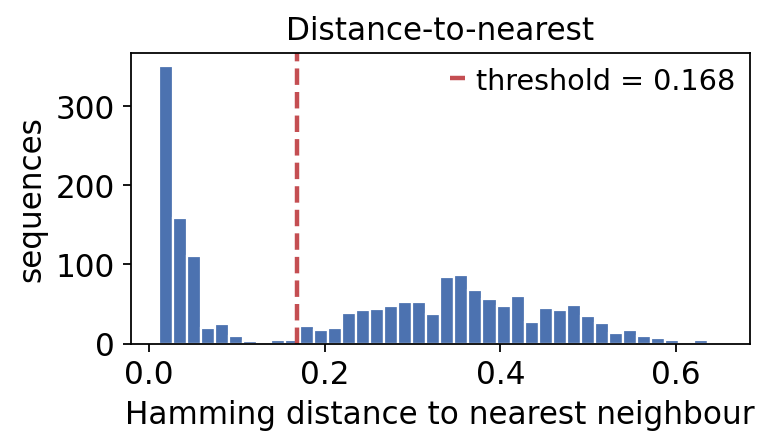

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(dist, bins=40, color='#4C72B0', edgecolor='white')
ax.axvline(threshold, color='#C44E52', ls='--', lw=2,
           label=f'threshold = {threshold:.3f}')
ax.set_xlabel('Hamming distance to nearest neighbour')
ax.set_ylabel('sequences'); ax.legend(); ax.set_title('Distance-to-nearest')
plt.tight_layout(); plt.show()

### Clonal clustering

We pass that threshold to `ov.airr.clonal_clustering`. The
`hierarchical` method groups sequences within each V/J/junction-length
partition by hierarchical clustering of junction distances; `complete`
linkage keeps clones tight (every member within-threshold of every other),
which avoids chaining a whole gene family into one giant pseudo-clone.

The source table already carries a `clone_id`; we drop it so the clustering
writes its own.

In [9]:
clones = ov.airr.clonal_clustering(
    db.drop(columns=['clone_id']),
    method='hierarchical', threshold=threshold, linkage='complete',
)
sizes = clones['clone_id'].value_counts()
print(f"B-cell clones inferred: {clones['clone_id'].nunique()}")
print(f"  singletons:          {(sizes == 1).sum()}")
print(f"  expanded (>=3 seqs): {(sizes >= 3).sum()}")
print(f"  largest clone:       {sizes.iloc[0]} sequences")

B-cell clones inferred: 1018
  singletons:          894
  expanded (>=3 seqs): 49
  largest clone:       165 sequences


Most clones are **singletons** -- sampled once, never expanded. A small
set of **expanded clones** carries many sequences each: these are the
proliferating, antigen-responding lineages. Plotting the clone-size rank
curve makes the skew obvious.

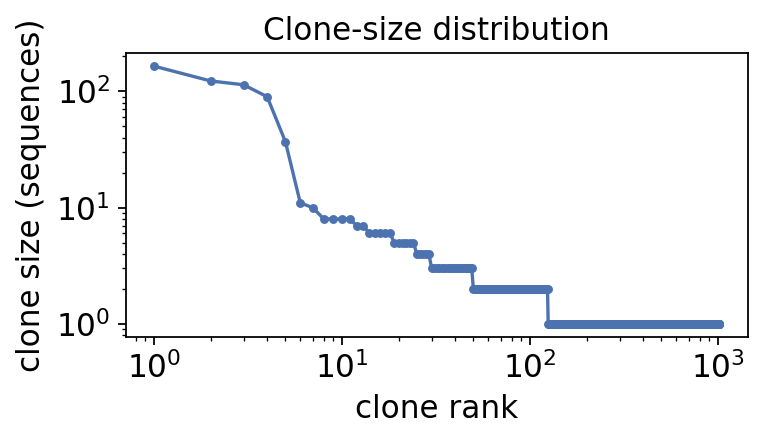

In [10]:
rank = np.arange(1, len(sizes) + 1)
fig, ax = plt.subplots(figsize=(5, 3))
ax.loglog(rank, sizes.values, marker='o', ms=3, color='#4C72B0')
ax.set_xlabel('clone rank'); ax.set_ylabel('clone size (sequences)')
ax.set_title('Clone-size distribution')
plt.tight_layout(); plt.show()

### Are the expanded clones the vaccine response?

If expansion is vaccine-driven, the largest clones should be enriched at
**day 7**, not pre-vaccination. We cross-tabulate the biggest clones by
timepoint.

In [11]:
tp = ov.airr.clone_timepoint_distribution(clones, min_size=8)
print(tp.head(8))
day7_frac = tp.attrs['timepoint_share']['+7d']
print(f"\nday-7 share of the largest clones: {day7_frac:.0%}")

sample_id  +7d  -1h
clone_id           
1010       165    0
1016       123    0
1013       114    0
1011        90    0
1014        37    0
1012        11    0
940         10    0
1015         8    0

day-7 share of the largest clones: 98%


The largest clones are overwhelmingly **day-7** sequences -- clonal
expansion is the first fingerprint of the vaccine response.

## 4. Clonal structure, diversity and germline reconstruction

Counting clones tells us *how many* lineages there are; it does not capture
how **evenly** the repertoire is divided among them. A vaccine response
collapses that evenness -- a few expanded clones come to own most of the
repertoire. Two complementary Immcantation tools quantify this.

### 4.1 Clonal rank-abundance

`ov.airr.clonal_abundance` (wrapping `pyalakazam.estimateAbundance`)
estimates, per clone, its **relative abundance** in the repertoire, with
bootstrap confidence intervals and rarefaction to a common depth so the two
timepoints are directly comparable.

In [12]:
abund, abund_df = ov.airr.clonal_abundance(
    clones, clone='clone_id', group='sample_id',
    nboot=200, seed=0, as_curve_data=True)
top = (abund_df.sort_values(['sample_id', 'rank'])
       .groupby('sample_id').head(3))
print("top-3 clones per timepoint (rarefied abundance +/- CI):")
print(top[['sample_id', 'rank', 'p', 'lower', 'upper']]
      .round(3).to_string(index=False))

top-3 clones per timepoint (rarefied abundance +/- CI):
sample_id  rank     p  lower  upper
      +7d     1 0.194  0.166  0.222
      +7d     2 0.146  0.123  0.168
      +7d     3 0.136  0.114  0.159
      -1h     1 0.008  0.002  0.015
      -1h     2 0.008  0.001  0.014
      -1h     3 0.007  0.001  0.013


The rank-abundance **curve** makes the contrast visible: a steep,
top-heavy curve means a few clones dominate; a shallow curve means an even
repertoire. `ov.airr.clonal_abundance_plot` draws it with the bootstrap CI
ribbons.

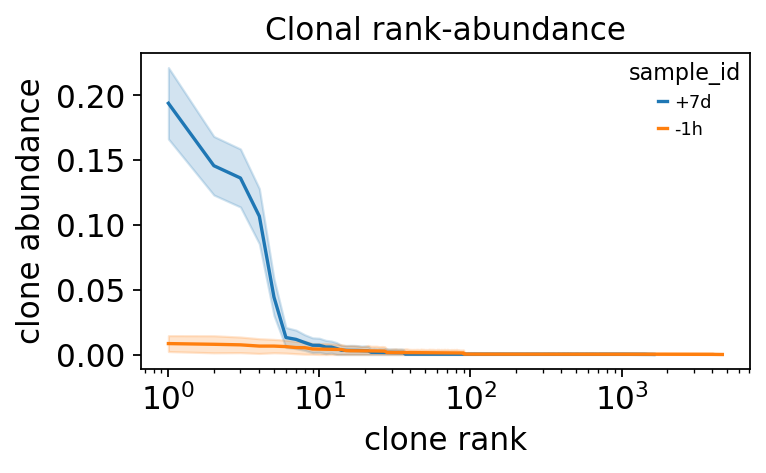

In [13]:
ax = ov.airr.clonal_abundance_plot(abund, figsize=(5, 3.2),
                                  title='Clonal rank-abundance')
plt.tight_layout(); plt.show()

The **day-7** curve starts far higher at rank 1 and falls away
steeply -- a handful of vaccine-driven clones each occupy a large slice of
the repertoire. The **pre-vaccination** curve is flatter: the resting
repertoire is divided much more evenly. Clonal expansion is, quantitatively,
a loss of repertoire evenness.

### 4.2 Hill-number diversity profile

A single diversity number is ambiguous -- richness, Shannon and Simpson
indices can disagree. The **Hill diversity profile** resolves this: it
reports diversity as a continuous function of the order `q`. At `q=0` it is
plain **clone richness**; at `q=1` it weights clones by frequency
(**Shannon**); at `q=2` it is dominated by the largest clones (**Simpson**).
A repertoire skewed by clonal expansion shows a profile that *drops sharply*
as `q` rises.

In [14]:
div = ov.airr.hill_diversity(clones, group='sample_id',
                             min_q=0, max_q=4, step_q=0.25)
dtab = div.diversity
q_show = dtab[dtab['q'].isin([0.0, 1.0, 2.0])]
print("Hill diversity at q = 0 (richness), 1 (Shannon), 2 (Simpson):")
print(q_show[['sample_id', 'q', 'd', 'd_lower', 'd_upper']]
      .round(1).to_string(index=False))

Hill diversity at q = 0 (richness), 1 (Shannon), 2 (Simpson):
sample_id   q     d  d_lower  d_upper
      +7d 0.0 235.1    211.5    258.6
      +7d 1.0  34.9     28.9     40.8
      +7d 2.0  10.8      9.6     12.0
      -1h 0.0 693.3    671.3    715.4
      -1h 1.0 619.8    585.7    653.8
      -1h 2.0 501.9    444.8    559.1


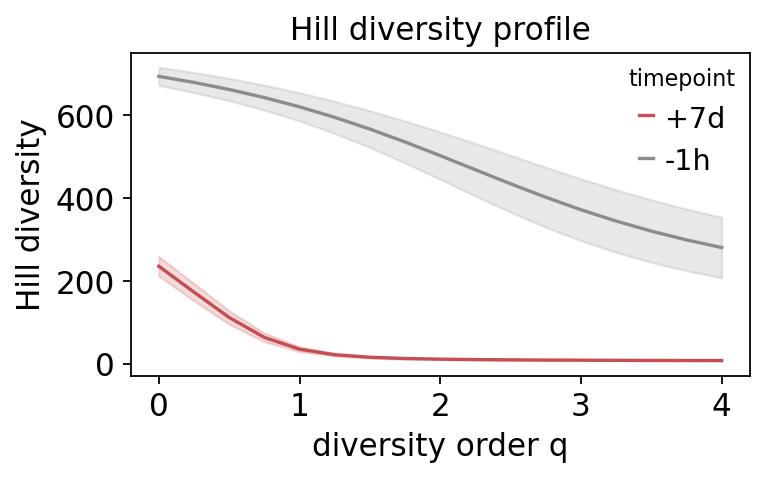

In [15]:
fig, ax = plt.subplots(figsize=(5, 3.2))
for name, sub in dtab.groupby('sample_id'):
    sub = sub.sort_values('q')
    color = '#C44E52' if name == '+7d' else '#8C8C8C'
    ax.plot(sub['q'], sub['d'], color=color, label=name)
    ax.fill_between(sub['q'], sub['d_lower'], sub['d_upper'],
                    color=color, alpha=0.2)
ax.set_xlabel('diversity order q'); ax.set_ylabel('Hill diversity')
ax.set_title('Hill diversity profile'); ax.legend(title='timepoint')
plt.tight_layout(); plt.show()

Both timepoints start near the same **richness** (`q=0`), but the
**day-7** profile collapses far faster as `q` increases: once clones are
weighted by frequency, the day-7 repertoire is much *less* diverse, because
a few expanded clones dominate it. The pre-vaccination profile stays flat --
an even repertoire with no dominant clones. The diverging Hill curves are
the diversity signature of the vaccine response.

### 4.3 Germline reconstruction -- the reference every SHM call needs

Every downstream step -- SHM frequency, BASELINe selection, lineage trees --
is computed by comparing each observed sequence to the **unmutated germline**
it derived from. That germline is not observed; it is *reconstructed* per
clone from the IMGT V/D/J reference. This is the core Immcantation
preprocessing step, exposed as `ov.airr.reconstruct_germlines` (wrapping
`pydowser.createGermlines`).

It takes a nested IMGT reference -- `{locus: {'V': ..., 'D': ..., 'J': ...}}`,
typically from `pydowser.readIMGT` -- plus the V/D/J germline-index columns
(`v_germline_start/end` ...) that an aligner such as IgBLAST writes. For
**each clone** it rebuilds the consensus germline and adds the
`germline_alignment` / `germline_alignment_d_mask` columns.

In [16]:
import inspect
sig = inspect.signature(ov.airr.reconstruct_germlines)
print("ov.airr.reconstruct_germlines parameters:")
for name, p in sig.parameters.items():
    if name not in ('db', 'kwargs'):
        print(f"  {name:14s} = {p.default}")

ov.airr.reconstruct_germlines parameters:
  references     = <class 'inspect._empty'>
  locus          = locus
  seq            = sequence_alignment
  v_call         = v_call
  d_call         = d_call
  j_call         = j_call
  clone          = clone_id
  fields         = None
  trim_lengths   = False
  na_rm          = True


The Laserson dataset is already **IMGT-aligned and germline-annotated**
-- it ships with both germline columns populated, so the SHM and selection
sections below can run directly. We verify they are present and intact: the
`germline_alignment_d_mask` differs from the plain `germline_alignment` only
in having the hypervariable D segment masked with `N` (the D call is too
short to assign reliably, so it is excluded from mutation counting).

In [17]:
gl_cols = ['germline_alignment', 'germline_alignment_d_mask']
present = [c for c in gl_cols if c in clones.columns]
print(f"germline columns present: {present}")
ex = clones[clones['germline_alignment_d_mask'].notna()].iloc[0]
n_mask = ex['germline_alignment_d_mask'].count('N')
print(f"germline length: {len(ex['germline_alignment'])} bp")
print(f"D-region positions masked with 'N': {n_mask}")
print(f"non-null germlines: {clones['germline_alignment_d_mask'].notna().sum()}"
      f" / {len(clones)} sequences")

germline columns present: ['germline_alignment', 'germline_alignment_d_mask']
germline length: 433 bp
D-region positions masked with 'N': 79
non-null germlines: 1780 / 1780 sequences


Both germline columns are present and complete -- the germline
reconstruction `ov.airr.reconstruct_germlines` performs was already applied
when the dataset was built. To run it from scratch you would supply your own
IMGT reference, e.g.:

```python
import pydowser
references = pydowser.readIMGT('/path/to/IMGT/human/vdj')
clones = ov.airr.reconstruct_germlines(clones, references=references)
```

Reconstruction needs a **complete** IMGT V/D/J set covering every allele the
aligner called; with the full reference in place, the `germline_alignment`
columns we just verified are exactly what it produces. With the germline
confirmed, we can now quantify how far each sequence has mutated *away* from
it.

## 5. Somatic hypermutation

Affinity maturation runs on mutation. `ov.airr.mutation_analysis` compares
each sequence's `sequence_alignment` to its `germline_alignment_d_mask` and
counts the substitutions. Mutations are classified as:

- **Replacement (R)** -- change the encoded amino acid (can alter affinity).
- **Silent (S)** -- synonymous (visible to AID, invisible to selection).

With `combine=True` we get a single whole-V-region **mutation frequency**
(mutations per base) per sequence -- the standard scalar measure of how
hypermutated a B cell is.

In [18]:
mut = ov.airr.mutation_analysis(clones, frequency=True, combine=True)
mut = mut.rename(columns={'mu_freq': 'shm_freq'})
print(f"mean SHM frequency: {mut['shm_freq'].mean():.3f}  "
      f"({mut['shm_freq'].mean() * 100:.1f}% of V-region bases mutated)")
print(f"range: {mut['shm_freq'].min():.3f} - {mut['shm_freq'].max():.3f}")

mean SHM frequency: 0.041  (4.1% of V-region bases mutated)
range: 0.000 - 0.218


A mean of ~4% mutated bases is typical for a mixed memory/naive IgH
repertoire. The real question is whether SHM **rose with vaccination** -- so
we split it by timepoint and by isotype.

In [19]:
by_time = ov.airr.summarize_by_group(mut['shm_freq'], group=mut['sample_id'],
                                     agg='mean')['shm_freq']
by_iso = ov.airr.summarize_by_group(mut['shm_freq'], group=mut['c_call'],
                                    agg='mean')['shm_freq']
print("mean SHM by timepoint:")
print((by_time * 100).round(1).astype(str) + ' %')
print("\nmean SHM by isotype:")
print((by_iso * 100).round(1).astype(str) + ' %')

mean SHM by timepoint:
sample_id
+7d    6.6 %
-1h    1.9 %
Name: shm_freq, dtype: object

mean SHM by isotype:
c_call
IGHA    7.7 %
IGHD    0.5 %
IGHG    7.8 %
IGHM    0.9 %
Name: shm_freq, dtype: object


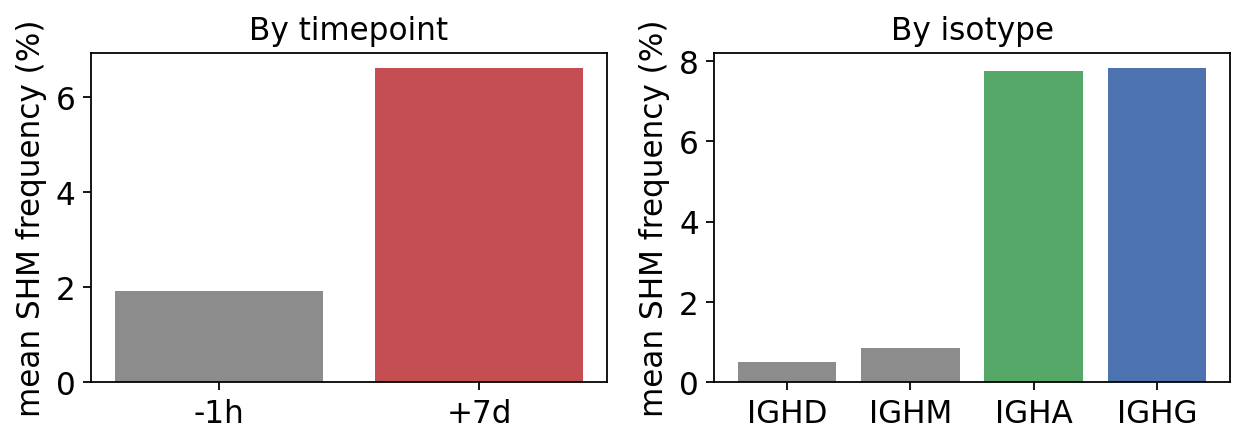

In [20]:
order_t, order_i = ['-1h', '+7d'], ['IGHD', 'IGHM', 'IGHA', 'IGHG']
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].bar(order_t, [by_time[t] * 100 for t in order_t], color=['#8C8C8C', '#C44E52'])
ax[1].bar(order_i, [by_iso[i] * 100 for i in order_i],
          color=['#8C8C8C', '#8C8C8C', '#55A868', '#4C72B0'])
ax[0].set_title('By timepoint'); ax[1].set_title('By isotype')
for a in ax: a.set_ylabel('mean SHM frequency (%)')
plt.tight_layout(); plt.show()

### Where in the V gene does SHM land?

A single whole-V mutation frequency hides *where* the mutations fall. The
V gene is built of alternating **framework regions** (FWR1-3, the structural
scaffold) and **complementarity-determining regions** (CDR1-2, the
antigen-contacting loops). Passing `region='v'` to `ov.airr.mutation_analysis`
splits the mutation count into one R and one S column **per IMGT sub-region**
-- the spatial map that the BASELINe selection test in the next section turns
into a selection signal.

In [21]:
mut_reg = ov.airr.mutation_analysis(clones, frequency=True,
                                   combine=False, region='v')
regions = ['fwr1', 'cdr1', 'fwr2', 'cdr2', 'fwr3']
reg_freq = ov.airr.mutation_by_region(mut_reg, regions=regions)
print("mean SHM frequency by IMGT V-region:")
for r in regions:
    print(f"  {r.upper():5s}: {reg_freq[r] * 100:.2f} %")

mean SHM frequency by IMGT V-region:
  FWR1 : 2.65 %
  CDR1 : 5.05 %
  FWR2 : 2.95 %
  CDR2 : 7.99 %
  FWR3 : 4.24 %


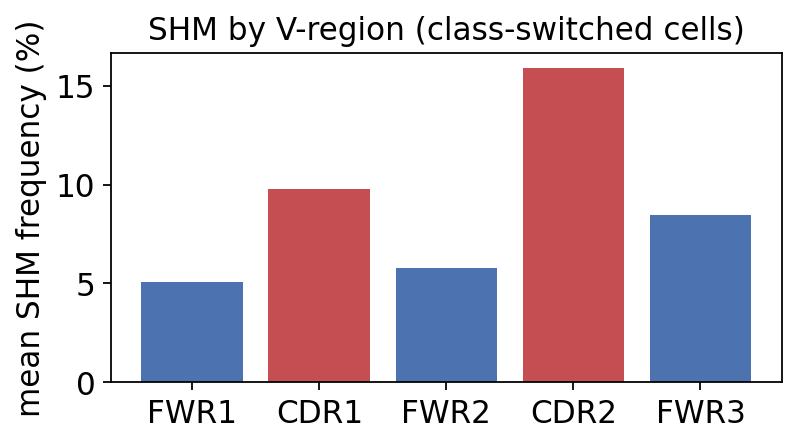

In [22]:
switched = mut_reg['c_call'].isin(['IGHG', 'IGHA'])
sw_freq = ov.airr.mutation_by_region(mut_reg, regions=regions, subset=switched)
cols = ['#4C72B0' if r.startswith('fwr') else '#C44E52' for r in regions]
fig, ax = plt.subplots(figsize=(5.2, 3))
ax.bar([r.upper() for r in regions], sw_freq.values * 100, color=cols)
ax.set_ylabel('mean SHM frequency (%)')
ax.set_title('SHM by V-region (class-switched cells)')
plt.tight_layout(); plt.show()

The **CDR1 and CDR2** loops carry a *higher* mutation frequency than
the flanking framework regions. This is the spatial fingerprint of affinity
maturation: AID scatters mutations across the whole V gene, but the
antigen-contacting CDRs accumulate and *retain* more of them, because that is
where affinity-improving changes can occur. The framework regions stay
comparatively clean. The next section makes this rigorous -- testing whether
the CDR-vs-FWR difference exceeds what AID targeting alone would produce.

Two textbook signatures. **SHM roughly triples from pre-vaccination to
day 7** -- the day-7 repertoire is dominated by hypermutated, germinal-centre
graduates. And SHM tracks isotype almost perfectly: **naive IgM/IgD are
near-germline**, while **class-switched IgG/IgA carry heavy SHM loads** --
exactly as expected, since class switching and SHM are co-induced in the
germinal centre.

### The SHM targeting model

AID does not mutate uniformly -- its activity depends on the local DNA
sequence context (the classic **WRC/GYW hotspot** motifs).
`ov.airr.shm_targeting` learns a **targeting model** directly from the
observed sequences: a per-5-mer mutability profile plus a substitution
matrix, fitted from every mutation in the dataset.

In [23]:
tmodel = ov.airr.shm_targeting(clones, minNumMutations=20,
                               minNumSeqMutations=200)
mutability = pd.Series(tmodel.mutability, index=tmodel.mut_names).dropna()
top = mutability.sort_values(ascending=False).head(8)
print("most mutable 5-mer motifs (centre base is the mutated position):")
print(top.round(3))

most mutable 5-mer motifs (centre base is the mutated position):
TTGTA    0.012
AGACA    0.010
GCGCG    0.009
AAGCG    0.009
AAATC    0.008
GAATA    0.008
AAATG    0.008
AAATT    0.008
dtype: float64


The 5-mers ranked here are the most mutable contexts *this subject's*
data supports -- with a few hundred mutations the estimates are noisy, so the
canonical `WRC`/`GYW` enrichment is only partly resolved (a deep repertoire
sharpens it). The point is the model itself: it is what makes the BASELINe
selection test in the next section rigorous, by providing the *null
expectation* of where mutations would land **in the absence of
selection**.

## 6. Antigen-driven selection -- the BASELINe framework

SHM scatters mutations; **selection** decides which survive. The
**BASELINe** framework (Yaari et al. 2012) tests this. The logic:

- Silent (S) mutations are invisible to selection -- they fix the *neutral
  mutation rate*.
- Given that rate and the SHM targeting model, BASELINe predicts the
  **expected number of replacement (R) mutations** per region under
  neutrality.
- The deviation of *observed* from *expected* R mutations is the **selection
  strength Sigma** (`baseline_sigma`):
  - **Sigma > 0** -- more R mutations than expected -> **positive selection**
    (affinity-improving changes are retained; expected in **CDRs**).
  - **Sigma < 0** -- fewer R mutations than expected -> **negative / purifying
    selection** (R changes are removed; expected in **FWRs**, which must stay
    structurally intact).

`ov.airr.baseline_selection` builds per-clone consensus sequences, runs the
BASELINe calculation per IMGT region, and summarises Sigma with a confidence
interval and p-value. We run it on the **expanded clones** (>=3 sequences) --
the lineages that have actually undergone enough SHM to test.

In [24]:
expanded = clones[clones['clone_id'].isin(sizes[sizes >= 3].index)].copy()
print(f"expanded-clone sequences: {len(expanded)}  "
      f"in {expanded['clone_id'].nunique()} clones")
selection = ov.airr.baseline_selection(expanded, region='v').drop_duplicates()
print(selection.round(3).to_string(index=False))

expanded-clone sequences: 736  in 49 clones


region  baseline_sigma  baseline_ci_lower  baseline_ci_upper  baseline_ci_pvalue
  cdr1          -0.014             -0.554              0.572              -0.466
  cdr2           0.041             -0.397              0.512               0.441
  fwr1          -1.011             -1.596             -0.442              -0.000
  fwr2          -0.763             -1.315             -0.201              -0.005
  fwr3          -0.667             -0.926             -0.413              -0.000


Reading the table by region:

- **FWR1, FWR2, FWR3** -- strongly **negative Sigma** (about -0.7 to -1.0),
  all with **p < 0.01**. The framework regions are under significant
  **purifying selection**: replacement mutations there break the
  immunoglobulin fold, so they are purged.
- **CDR1, CDR2** -- Sigma about 0, **not significant**. The antigen-contacting
  loops are *released from that constraint* -- replacement mutations there are
  tolerated rather than purged.

The biologically meaningful quantity is the **CDR-minus-FWR contrast**: CDRs
are free to accept affinity-altering mutations precisely where FWRs are not.
That differential is the molecular signature of antigen-driven selection.

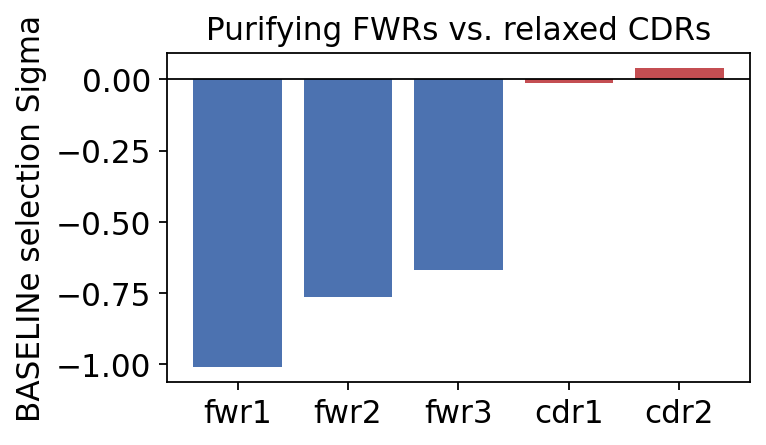

In [25]:
piv = selection.set_index('region')['baseline_sigma']
reg = ['fwr1', 'fwr2', 'fwr3', 'cdr1', 'cdr2']
colors = ['#4C72B0' if r.startswith('fwr') else '#C44E52' for r in reg]
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(reg, [piv[r] for r in reg], color=colors)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('BASELINe selection Sigma')
ax.set_title('Purifying FWRs vs. relaxed CDRs')
plt.tight_layout(); plt.show()

### Does selection differ between naive and switched cells?

If selection is antigen-driven, it should be sharper in the
**class-switched** (germinal-centre-experienced) compartment. We group the
BASELINe scores by isotype class.

In [26]:
expanded['isotype_class'] = ov.airr.isotype_class(expanded)
sel_grp = ov.airr.baseline_selection(
    expanded, group_by='isotype_class', region='v').drop_duplicates()
print(sel_grp.round(3).to_string(index=False))

isotype_class region  baseline_sigma  baseline_ci_lower  baseline_ci_upper  baseline_ci_pvalue
     switched   cdr1          -0.012             -0.565              0.589              -0.469
     switched   cdr2           0.025             -0.415              0.497               0.470
     switched   fwr1          -1.022             -1.624             -0.437              -0.001
     switched   fwr2          -0.820             -1.379             -0.251              -0.003
     switched   fwr3          -0.664             -0.927             -0.406              -0.000
        naive   cdr1          -0.085             -1.539              1.566              -0.437
        naive   cdr2           0.623             -2.189              5.254               0.423
        naive   fwr1          -0.651             -2.199              0.886              -0.196
        naive   fwr2           1.301             -1.310              5.590               0.229
        naive   fwr3          -0.771             -

The **class-switched** clones show the clean, significant
FWR-purifying pattern; the naive clones -- near-germline, barely mutated --
have wide confidence intervals and no significant selection, because there
simply has not been enough SHM for selection to act on. Selection is a
property of the *antigen-experienced* repertoire.

## 7. B-cell lineage trees

A **lineage tree** is the phylogeny *inside* a single clone. Its root is the
inferred unmutated common ancestor (the naive germline V(D)J); each branch is
an SHM step; each tip is an observed cell. The tree shows the *order* in
which mutations were acquired and how the clone diversified -- the
affinity-maturation trajectory itself.

`ov.airr.lineage_trees` formats each clone and builds a maximum-parsimony
tree (`pydowser`). Tree-building needs **one consensus germline per clone**,
so we first collapse each clone's germline to its position-wise majority
sequence. We build trees for several moderately expanded clones (parsimony on
the very largest clones is slow and adds no extra concepts).

In [27]:
pick = sizes[(sizes >= 8) & (sizes <= 37)].index[:5]
tree_in = ov.airr.collapse_germlines(
    clones[clones['clone_id'].isin(pick)].copy())
print(f"building lineage trees for {tree_in['clone_id'].nunique()} clones")

building lineage trees for 5 clones


In [28]:
trees = ov.airr.lineage_trees(tree_in, build='pratchet')
summary = pd.DataFrame({
    'clone_id': trees['clone_id'],
    'n_tips': [t.n_tip for t in trees['trees']],
    'tree_length': [round(sum(t.edge_length), 3) for t in trees['trees']],
})
print(summary.to_string(index=False))

clone_id  n_tips  tree_length
    1014      19        0.182
     940      10        0.168
     107       7        0.102
    1015       6        0.078
    1012       5        0.081


Each row is one clone's tree: `n_tips` distinct sequences connected by a
total branch length (`tree_length`) measured in substitutions. A larger tree
length means a clone that has accumulated more SHM diversity -- it has been
maturing longer or harder. We draw the trees with `pydowser`.

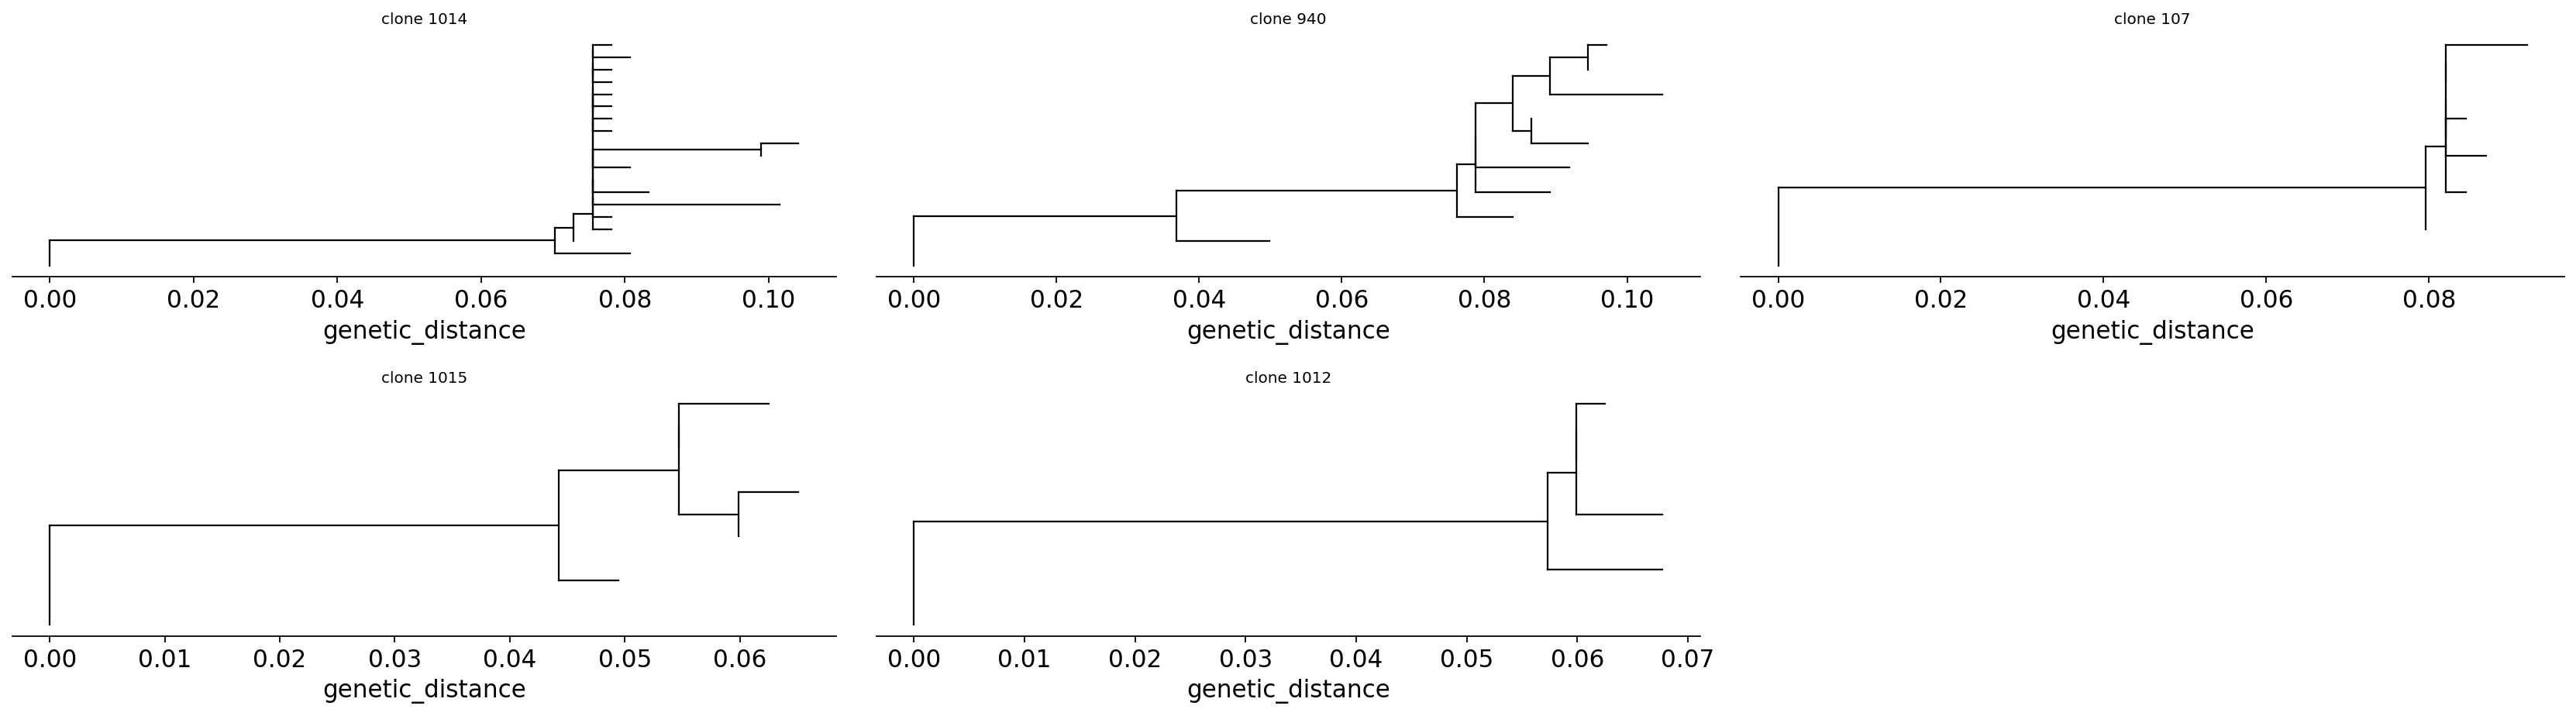

In [29]:
import pydowser
axes = pydowser.plotTrees(trees, scale=True, tip_labels=False, ncol=3)
for ax, cid in zip(axes, trees['clone_id']):
    ax.set_title(f'clone {cid}', fontsize=9)
plt.tight_layout(); plt.show()

Each tree fans out from the germline root. The **branching topology** is
the affinity-maturation history made visible: long internal branches are
bursts of SHM, and clusters of closely related tips are sub-lineages of
related affinity variants -- the population that selection was choosing
between. A clone that is a deep, well-resolved tree (rather than a star of
identical sequences) is one that genuinely diversified inside a germinal
centre.

## 8. V-gene genotype

Every SHM and selection call is made *relative to the germline*. But germline
IGHV alleles are **polymorphic** between individuals -- using the wrong allele
as reference would mis-score the first few "mutations". `pytigger` infers the
subject's personal IGHV genotype straight from the data.

`ov.airr.infer_genotype` keeps, for each V gene, only the alleles a person
actually carries -- judged from the alleles seen on **unmutated** sequences
(where the call is unambiguous). The Immcantation-style gene calls in this
dataset carry a `Homsap ... F` prefix, so we strip them to bare allele names
first.

In [30]:
import pytigger
geno_in = ov.airr.normalize_gene_calls(clones, cols=('v_call', 'j_call'))
germline_ighv = pytigger.load_sample_germline_ighv()
print(f"IMGT germline IGHV reference: {len(germline_ighv)} alleles")

IMGT germline IGHV reference: 344 alleles


In [31]:
genotype = ov.airr.infer_genotype(geno_in, germline_db=germline_ighv,
                                  method='frequency')
print(f"IGHV genes in this subject's genotype: {len(genotype)}")
het = genotype[genotype['alleles'].str.contains(',')]
print(f"heterozygous genes (>1 allele): {len(het)}")
print(genotype[['gene', 'alleles', 'counts']].head(8).to_string(index=False))

IGHV genes in this subject's genotype: 40
heterozygous genes (>1 allele): 9
    gene  alleles counts
 IGHV1-2    02,04    2,1
 IGHV1-3       01      9
 IGHV1-8       01      9
IGHV1-18       01      7
IGHV1-24       01      9
IGHV1-46       01      4
IGHV1-58       02      5
IGHV1-69 02,01,06  8,8,7


The genotype lists the IGHV genes this individual uses and which
allele(s) of each -- most genes appear with a single allele, a few are
**heterozygous**. Pinning the genotype this way is what makes the SHM and
selection scores above germline-accurate rather than confounded by allelic
polymorphism.

### Novel alleles

`ov.airr.find_novel_alleles` goes one step further: it looks for IGHV alleles
**not in the IMGT reference at all**, by testing whether apparent "mutations"
at specific positions accumulate in a way that betrays an unrecorded germline
polymorphism rather than SHM.

In [32]:
novel = ov.airr.find_novel_alleles(geno_in, germline_ighv)
n_novel = int(novel['polymorphism_call'].notna().sum())
print(f"candidate novel IGHV alleles: {n_novel}")
print(f"genes screened: {len(novel)}")

candidate novel IGHV alleles: 0
genes screened: 1


No novel alleles pass here -- expected for a single subject at this
sequencing depth (novel-allele discovery needs many unmutated sequences per
gene). The screen ran cleanly, confirming the IMGT reference is adequate for
this subject.

## 8.5 Isotype composition and CDR3 properties

The constant-region call `c_call` records which **antibody class** each B cell
expresses -- the last axis of the affinity-maturation story. Naive B cells
co-express **IgM** and **IgD**; on antigen activation, germinal-centre B cells
**class-switch** their constant region to **IgG** or **IgA**, irreversibly
deleting the upstream IgM/IgD exons. Because class switching and SHM are both
AID-driven and co-induced, the switched isotypes are exactly the
hypermutated, selected, affinity-matured compartment.

### Isotype distribution across the response

We tabulate `c_call` by timepoint to see the class-switch shift the vaccine
induces.

In [33]:
iso_frac = ov.airr.isotype_composition(clones, group='sample_id')
print("isotype fraction by timepoint:")
print(iso_frac.round(3).to_string())
switch = iso_frac.attrs['switched_fraction']
print(f"\nclass-switched (IgG+IgA) fraction: "
      f"-1h {switch['-1h']:.0%}  ->  +7d {switch['+7d']:.0%}")

isotype fraction by timepoint:
c_call      IGHA   IGHD   IGHG   IGHM
sample_id                            
+7d        0.248  0.057  0.530  0.165
-1h        0.099  0.207  0.116  0.577

class-switched (IgG+IgA) fraction: -1h 22%  ->  +7d 78%


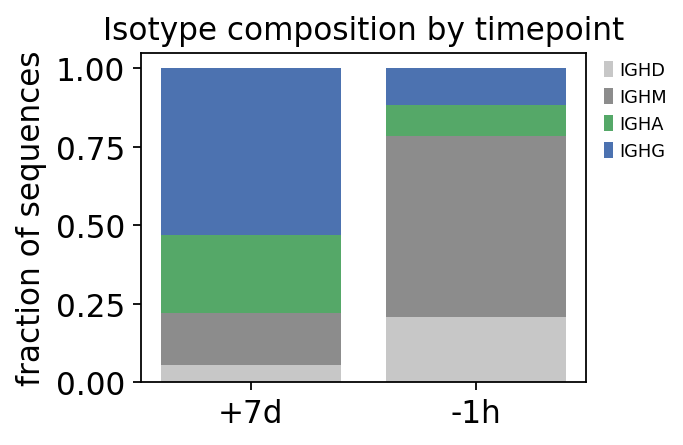

In [34]:
order_i = ['IGHD', 'IGHM', 'IGHA', 'IGHG']
pal = {'IGHD': '#C7C7C7', 'IGHM': '#8C8C8C',
       'IGHA': '#55A868', 'IGHG': '#4C72B0'}
fig, ax = plt.subplots(figsize=(4.5, 3))
bottom = np.zeros(len(iso_frac))
for iso in order_i:
    ax.bar(iso_frac.index, iso_frac[iso], bottom=bottom,
           color=pal[iso], label=iso)
    bottom += iso_frac[iso].values
ax.set_ylabel('fraction of sequences')
ax.set_title('Isotype composition by timepoint')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

The class-switched **IgG + IgA** fraction rises sharply from
pre-vaccination to day 7 -- the vaccine drives B cells through the germinal
centre, where they switch class. Combined with the earlier results, the
isotype axis ties the story together: the day-7 sequences are not just *more*
clones, they are *switched, hypermutated, selected* clones.

### CDR3 amino-acid properties

The **CDR3** is the most variable loop of the antibody and usually its
dominant antigen-contacting surface. Its **physicochemical** character --
length, hydrophobicity (GRAVY), net charge, polarity, side-chain bulkiness --
shapes what antigens it can bind. `ov.airr.aa_properties` translates the
`junction` nucleotide sequence and computes these properties per sequence
(wrapping `pyalakazam.aminoAcidProperties`).

In [35]:
aap = ov.airr.aa_properties(clones, seq='junction', nt=True)
prop_cols = ['junction_aa_length', 'junction_aa_gravy',
             'junction_aa_charge', 'junction_aa_polarity']
by_iso_aa = ov.airr.summarize_by_group(aap[prop_cols], group=aap['c_call'],
                                       agg='mean').loc[order_i]
print("mean CDR3 amino-acid properties by isotype:")
print(by_iso_aa.round(3).to_string())

mean CDR3 amino-acid properties by isotype:
        junction_aa_length  junction_aa_gravy  junction_aa_charge  junction_aa_polarity
c_call                                                                                 
IGHD                23.314             -0.363              -0.769                 8.011
IGHM                22.738             -0.401              -0.712                 8.104
IGHA                20.228             -0.295              -0.399                 8.317
IGHG                20.509             -0.399              -0.446                 8.385


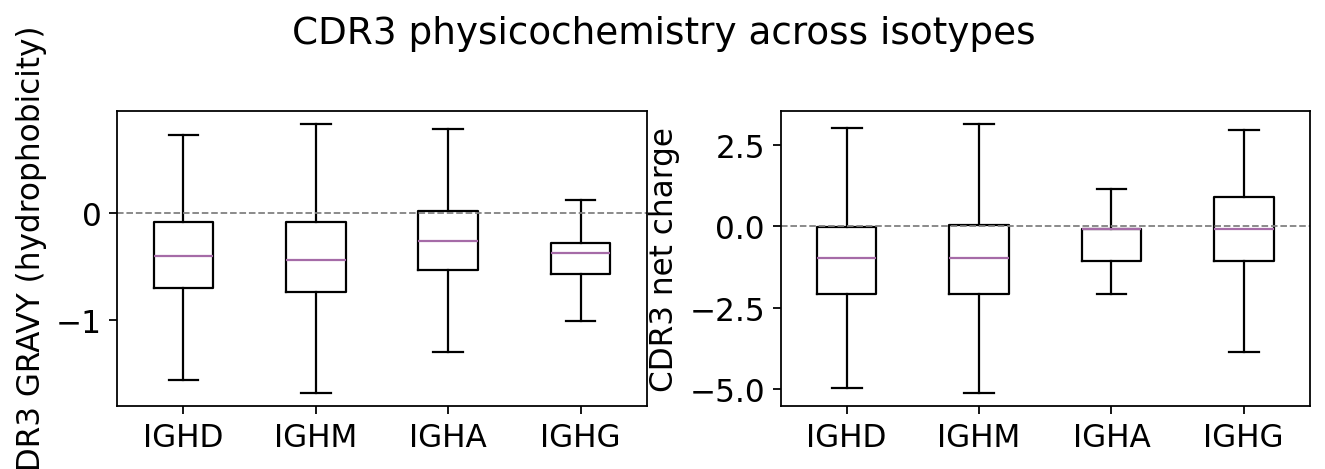

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(8.5, 3))
for a, (col, lab) in zip(ax, [('junction_aa_gravy', 'CDR3 GRAVY (hydrophobicity)'),
                              ('junction_aa_charge', 'CDR3 net charge')]):
    data = [aap.loc[aap['c_call'] == i, col].dropna() for i in order_i]
    a.boxplot(data, labels=order_i, showfliers=False)
    a.set_ylabel(lab)
ax[0].axhline(0, color='grey', lw=0.8, ls='--')
ax[1].axhline(0, color='grey', lw=0.8, ls='--')
fig.suptitle('CDR3 physicochemistry across isotypes')
plt.tight_layout(); plt.show()

The CDR3 loops are, on average, **hydrophilic** (negative GRAVY) --
expected for a solvent-exposed binding loop -- and carry a modest net charge.
Comparing the distributions across **naive (IgM/IgD)** and **switched
(IgG/IgA)** isotypes shows whether affinity maturation also nudges the
*chemistry* of the binding loop, not just its sequence. Any systematic shift
in CDR3 charge or hydrophobicity between the naive and switched compartments
is a property-level echo of antigen-driven selection.

## 9. Synthesis -- the affinity-maturation picture

Every step has added one panel to the same story. Putting them side by side:

In [37]:
fwr_sig, cdr_sig = piv[['fwr1','fwr2','fwr3']].mean(), piv[['cdr1','cdr2']].mean()
report = {
    'B-cell clones / expanded': f"{clones['clone_id'].nunique()} / {(sizes >= 3).sum()}",
    'day-7 share of top clones': f"{day7_frac:.0%}",
    'mean SHM  -1h -> +7d': f"{by_time['-1h']*100:.1f}% -> {by_time['+7d']*100:.1f}%",
    'BASELINe Sigma  FWR / CDR': f"{fwr_sig:+.2f} / {cdr_sig:+.2f}",
}
for k, v in report.items():
    print(f"  {k:<28s}: {v}")

  B-cell clones / expanded    : 1018 / 49
  day-7 share of top clones   : 98%
  mean SHM  -1h -> +7d        : 1.9% -> 6.6%
  BASELINe Sigma  FWR / CDR   : -0.81 / +0.01


**The molecular fossil record of a vaccine response.** From a single
subject's IgH repertoire, `ov.airr` reconstructed the coupled engines of
affinity maturation, end to end:

1. **Gene usage** -- `bcr_gene_usage` profiled V/D/J segment usage; the
   repertoire is dominated by the IGHV3 and IGHV4 families, the expected
   human IgH hierarchy.

2. **Clonal expansion** -- hierarchical clonal clustering resolved the
   repertoire into B-cell clones; `clonal_abundance` and the **Hill diversity
   profile** showed the day-7 repertoire collapsing in evenness as a few
   vaccine-driven clones come to dominate it.

3. **Germline reconstruction** -- the `germline_alignment` columns that every
   downstream step compares against were verified;
   `ov.airr.reconstruct_germlines` is the Immcantation step that builds them
   from the IMGT reference.

4. **Somatic hypermutation** -- comparing each sequence to its germline showed
   SHM **rising roughly 3-fold from pre-vaccination to day 7** (1.9% to 6.6%),
   tracking isotype, and -- resolved **by IMGT region** -- concentrating in
   the antigen-contacting CDR1/CDR2 loops. A 5-mer **targeting model** was
   fitted to supply the neutral mutation expectation.

5. **Antigen-driven selection** -- the **BASELINe** test showed significant
   **purifying selection in the framework regions** (Sigma < 0, p < 0.01) and
   **relaxed CDRs** (Sigma about 0). The framework is held intact while the
   antigen-contacting loops are free to mutate -- the CDR-vs-FWR contrast that
   defines selection. The signal is carried by the class-switched compartment.

6. **Lineage history** -- maximum-parsimony **lineage trees** turned each
   expanded clone into a phylogeny rooted at its naive ancestor, making the
   order of SHM events and the diversification of affinity variants explicit.

7. **Isotype and CDR3 chemistry** -- the class-switched IgG/IgA fraction rose
   with vaccination, and `aa_properties` profiled the physicochemistry of the
   CDR3 binding loop across isotypes.

8. **Germline calibration** -- `pytigger` inferred the subject's personal
   IGHV genotype, so every mutation above was scored against the correct
   germline.

Gene usage + clonal expansion + diversity collapse + somatic hypermutation +
framework-purifying / CDR-relaxed selection + class switching -- read
directly off the BCR repertoire -- *is* the signature of vaccine-induced
affinity maturation.